# Protein Embedding Layer Probe Sweep

Select a dataset from the unified probing catalog, choose a probe and embedding model, evaluate every layer, and plot the resulting performance.

The probing runner supports protein-level tasks and residue-level tasks when residue embeddings are generated without pooling.

In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import replace
import gc
import os
import math
import shutil
from pathlib import Path
import sys
from typing import Mapping, Sequence

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "CBBIO").exists() else NOTEBOOK_DIR.parent
if not (REPO_ROOT / "CBBIO").exists():
    raise RuntimeError("Could not find the CBBIO package directory. Start Jupyter from the repo root or notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm.auto import tqdm

def clear_runtime_caches(*, clear_embedding_cache: bool = True) -> None:
    """Release notebook-level caches before repeat runs."""
    if clear_embedding_cache:
        globals().pop("_emb_cache", None)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass


# Clean runtime caches when re-running the notebook in an existing kernel.
clear_runtime_caches()

from CBBIO import (
    available_generator_classes,
    available_generator_models,
    collect_generation_results,
    compute_residue_feature_stats,
    compute_residue_flat_data,
    filter_redundant_to_test_mmseqs,
    GenerationInput,
    Generator,
    PredictionSpec,
    ProbeSpec,
    ProteinDataset,
    ResidueDataset,
    Task,
    get_dataset_catalog_entry,
    list_dataset_catalog,
    load_dataset,
    load_peer_dataset,
    run_task_on_layer,
    search_dataset_catalog,
)
from CBBIO.embeddings import EmbeddingDependencyError, EmbeddingInputError

## Configuration

Start with a native PEER protein-level task. Set `DOWNLOAD_DATA = True` for the first run if the dataset is not already present under `DATA_ROOT`.

In [ ]:
DATA_ROOT = Path("data/probing")

# Either set DATASET_ID directly, or leave it as None and use DATASET_QUERY.
DATASET_ID: str | None ="go:go_mf_full"
DATASET_QUERY = "protein"

DOWNLOAD_DATA = True
PEER_SPLIT: str | Sequence[str] | None = None  # None uses the PEER benchmark split, e.g. fold -> test_fold_holdout

# Keep this small while iterating. Set to None for the full dataset.
MAX_TRAIN_EXAMPLES: int | None = 100000
MAX_VAL_EXAMPLES: int | None = 15000
MAX_TEST_EXAMPLES: int | None = 15000

# Optional MMseqs2 train/val-to-test redundancy filtering.
FILTER_REDUNDANT_TO_TEST = False
REDUNDANCY_IDENTITY_CUTOFF = 30.0
REDUNDANCY_MIN_COVERAGE = 0.8
REDUNDANCY_THREADS: int | None = None

# Embedding generation memory controls. Lower these if CUDA memory is tight.
EMBEDDING_BATCH_SIZE = 8
MAX_BATCH_TOKENS: int | None = 32768
MAX_SEQUENCE_LENGTH: int | None = 1024
LENGTH_SORT_WINDOW: int | None = 256  # Smaller window smooths peak memory; None disables length sorting.
POOLER: str | None = "auto"  # cls -> ESM-style sequence classification token; auto -> mean for protein tasks, none for residue tasks

# Limit CPU thread fan-out during embedding/probing work to avoid memory pressure and machine stalls.
MAX_CPU_THREADS: int | None = min(4, os.cpu_count() or 1)
MAX_TORCH_INTEROP_THREADS: int | None = 4
DISABLE_TOKENIZERS_PARALLELISM = False

# Small default model. Larger models are slower but can be swapped in here.
MODEL_CLASS = "esmc"
MODEL_NAME: str | None = "esmc_300m"  # None uses the selected model class default; set a string to override.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LAYER_STRIDE = 6
CUSTOM_LAYERS = None 

# Probe configuration and repeated-seed evaluation.
PROBE = ProbeSpec(kind="mlp", epochs=50, learning_rate=0.001, batch_size=8192, seed=7,hidden_dim=512)
PROBE_SEEDS: Sequence[int] = (7, 11, 23)
METRIC: str | None = None

# Checkpoint file for safe resume. Set to a Path string to enable persistence.
# Completed (seed, layer) runs are appended as JSONL; on restart those pairs are skipped.
RESULTS_PATH: str | None = None  # e.g. "data/probing/results.jsonl"

# ── Embedding cache settings ───────────────────────────────────────────────────
# LAYER_CACHE_DIR (recommended for layer sweeps): one HDF5 file per layer written
# during generation.  During the sweep each file is loaded sequentially — all
# proteins for that layer are contiguous so disk reads are O(N_proteins) not
# O(N_proteins × N_layers).  On HDD this can be 10-100× faster than the
# interleaved single-file layout.  Set to None to use EMBEDDINGS_CACHE_PATH instead.
LAYER_CACHE_DIR: str | None = "/scratch/layers_cache/"
CLEAN_LAYER_CACHE_BEFORE_GENERATION = True

# EMBEDDINGS_CACHE_PATH (legacy single-file mode): all layers interleaved in one
# file (protein-major layout).  Efficient for random-access by protein id; less
# efficient when every layer must be read for a sweep.  Ignored when LAYER_CACHE_DIR
# is set.
EMBEDDINGS_CACHE_PATH: str | None = None  # e.g. "data/probing/emb_cache/protT5_secondary_structure.h5"

## Apply Runtime Resource Limits

This notebook runs in a single process, but PyTorch, BLAS libraries, and tokenizers can still fan out across many CPU threads. Use these limits to keep memory-hungry steps from overwhelming the machine.

In [3]:
def apply_runtime_resource_limits(*, max_cpu_threads: int | None, max_torch_interop_threads: int | None, disable_tokenizers_parallelism: bool) -> None:
    thread_env = {
        "OMP_NUM_THREADS": max_cpu_threads,
        "MKL_NUM_THREADS": max_cpu_threads,
        "OPENBLAS_NUM_THREADS": max_cpu_threads,
        "NUMEXPR_NUM_THREADS": max_cpu_threads,
    }
    for name, value in thread_env.items():
        if value is None:
            os.environ.pop(name, None)
        else:
            os.environ[name] = str(int(value))

    if disable_tokenizers_parallelism:
        os.environ["TOKENIZERS_PARALLELISM"] = "false"
    else:
        os.environ.pop("TOKENIZERS_PARALLELISM", None)

    if max_cpu_threads is not None:
        torch.set_num_threads(int(max_cpu_threads))
    if max_torch_interop_threads is not None:
        try:
            torch.set_num_interop_threads(int(max_torch_interop_threads))
        except RuntimeError as exc:
            print(f"Could not update torch interop threads without a kernel restart: {exc}")

    print(
        "Applied resource limits:",
        {
            "max_cpu_threads": max_cpu_threads,
            "max_torch_interop_threads": max_torch_interop_threads,
            "tokenizers_parallelism": "false" if disable_tokenizers_parallelism else "auto",
        },
    )


apply_runtime_resource_limits(
    max_cpu_threads=MAX_CPU_THREADS,
    max_torch_interop_threads=MAX_TORCH_INTEROP_THREADS,
    disable_tokenizers_parallelism=DISABLE_TOKENIZERS_PARALLELISM,
)

Applied resource limits: {'max_cpu_threads': 4, 'max_torch_interop_threads': 4, 'tokenizers_parallelism': 'auto'}


## Optional HTML Widgets

Use this panel to update the configuration variables without editing code cells. After clicking `Apply widget values`, continue running the notebook from the dataset-selection cell below.

In [4]:
try:
    import ipywidgets as widgets
    from IPython.display import HTML, display
except Exception as exc:
    from IPython.display import HTML, display
    display(HTML(f"<p><strong>ipywidgets is unavailable.</strong> Edit the configuration cell instead. ({exc})</p>"))
else:
    def _ready_dataset_options(query: str = ""):
        entries = search_dataset_catalog(query, status="ready") if query.strip() else list_dataset_catalog(status="ready")
        return [(f"{entry.id} | {entry.display_name}", entry.id) for entry in entries]

    def _model_options(model_class: str) -> list[str]:
        values = available_generator_models(model_class)
        return list(values) if isinstance(values, list) else []

    dataset_search = widgets.Text(value=DATASET_QUERY, description="Search", layout=widgets.Layout(width="520px"))
    dataset_options = _ready_dataset_options(DATASET_QUERY)
    dataset_select = widgets.Dropdown(
        options=dataset_options or _ready_dataset_options(),
        value=DATASET_ID if DATASET_ID in {value for _label, value in (dataset_options or [])} else None,
        description="Dataset",
        layout=widgets.Layout(width="720px"),
    )
    search_button = widgets.Button(description="Search", button_style="")

    model_class_select = widgets.Dropdown(options=available_generator_classes(), value=MODEL_CLASS, description="Model class")
    model_name_select = widgets.Combobox(
        options=_model_options(MODEL_CLASS),
        value=MODEL_NAME or "",
        description="Model",
        ensure_option=False,
        placeholder="default for class",
        layout=widgets.Layout(width="420px"),
    )
    device_select = widgets.Dropdown(options=["cuda", "cpu"], value=DEVICE, description="Device")

    probe_kind_select = widgets.Dropdown(options=["linear", "mlp"], value=PROBE.kind, description="Probe")
    epochs_input = widgets.BoundedIntText(value=PROBE.epochs, min=1, max=10000, description="Epochs")
    lr_input = widgets.FloatLogSlider(value=PROBE.learning_rate, base=10, min=-5, max=0, step=0.1, description="LR")
    batch_input = widgets.BoundedIntText(value=PROBE.batch_size or 128, min=1, max=100000, description="Batch")
    hidden_input = widgets.BoundedIntText(value=PROBE.hidden_dim, min=1, max=4096, description="Hidden")

    layer_stride_input = widgets.BoundedIntText(value=LAYER_STRIDE, min=1, max=1000, description="Stride")
    custom_layers_input = widgets.Text(value="", description="Layers", placeholder="e.g. 0,5,10")
    metric_input = widgets.Text(value=METRIC or "", description="Metric", placeholder="auto")
    max_train_input = widgets.IntText(value=MAX_TRAIN_EXAMPLES or -1, description="Max train")
    max_val_input = widgets.IntText(value=MAX_VAL_EXAMPLES or -1, description="Max val")
    max_test_input = widgets.IntText(value=MAX_TEST_EXAMPLES or -1, description="Max test")
    redundancy_filter_input = widgets.Checkbox(value=FILTER_REDUNDANT_TO_TEST, description="Seq-id filter")
    redundancy_cutoff_input = widgets.FloatText(value=REDUNDANCY_IDENTITY_CUTOFF, description="% identity")
    redundancy_coverage_input = widgets.FloatText(value=REDUNDANCY_MIN_COVERAGE, description="Coverage")
    redundancy_threads_input = widgets.IntText(value=REDUNDANCY_THREADS or -1, description="MMseqs threads")
    embedding_batch_input = widgets.BoundedIntText(value=EMBEDDING_BATCH_SIZE, min=1, max=256, description="Emb batch")
    max_batch_tokens_input = widgets.IntText(value=MAX_BATCH_TOKENS or -1, description="Max tokens")
    max_sequence_length_input = widgets.IntText(value=MAX_SEQUENCE_LENGTH or -1, description="Max seq")
    length_sort_window_input = widgets.IntText(value=LENGTH_SORT_WINDOW or -1, description="Sort window")
    pooler_select = widgets.Dropdown(options=["cls", "auto", "mean", "none"], value=POOLER or "none", description="Pooler")
    cpu_threads_input = widgets.IntText(value=MAX_CPU_THREADS or -1, description="CPU threads")
    torch_interop_threads_input = widgets.IntText(value=MAX_TORCH_INTEROP_THREADS or -1, description="Interop")
    tokenizers_parallelism_input = widgets.Checkbox(value=DISABLE_TOKENIZERS_PARALLELISM, description="Disable tokenizer parallelism")
    download_data_input = widgets.Checkbox(value=DOWNLOAD_DATA, description="Download data")

    apply_button = widgets.Button(description="Apply widget values", button_style="primary")
    widget_status = widgets.HTML(value="")

    def _parse_optional_int(value: int) -> int | None:
        return None if int(value) < 0 else int(value)

    def _parse_custom_layers(value: str) -> list[int] | None:
        text = value.strip()
        if not text:
            return None
        return [int(part.strip()) for part in text.split(",") if part.strip()]

    def _parse_optional_text(value: str | None) -> str | None:
        text = value.strip() if isinstance(value, str) else ""
        return text or None

    def _refresh_dataset_options(_button=None):
        options = _ready_dataset_options(dataset_search.value)
        dataset_select.options = options or _ready_dataset_options()
        if dataset_select.options:
            dataset_select.value = dataset_select.options[0][1]

    def _refresh_model_options(change):
        options = _model_options(change["new"])
        model_name_select.options = options
        model_name_select.value = ""

    def _apply_widget_values(_button=None):
        global DATASET_ID, DATASET_QUERY, DOWNLOAD_DATA, MODEL_CLASS, MODEL_NAME, DEVICE
        global MAX_TRAIN_EXAMPLES, MAX_VAL_EXAMPLES, MAX_TEST_EXAMPLES, FILTER_REDUNDANT_TO_TEST, REDUNDANCY_IDENTITY_CUTOFF, REDUNDANCY_MIN_COVERAGE, REDUNDANCY_THREADS
        global EMBEDDING_BATCH_SIZE, MAX_BATCH_TOKENS, MAX_SEQUENCE_LENGTH, POOLER, MAX_CPU_THREADS, MAX_TORCH_INTEROP_THREADS, DISABLE_TOKENIZERS_PARALLELISM, LENGTH_SORT_WINDOW
        global LAYER_STRIDE, CUSTOM_LAYERS, PROBE, METRIC
        DATASET_ID = dataset_select.value
        DATASET_QUERY = dataset_search.value
        DOWNLOAD_DATA = bool(download_data_input.value)
        MODEL_CLASS = model_class_select.value
        MODEL_NAME = _parse_optional_text(model_name_select.value)
        DEVICE = device_select.value
        MAX_TRAIN_EXAMPLES = _parse_optional_int(max_train_input.value)
        MAX_VAL_EXAMPLES = _parse_optional_int(max_val_input.value)
        MAX_TEST_EXAMPLES = _parse_optional_int(max_test_input.value)
        FILTER_REDUNDANT_TO_TEST = bool(redundancy_filter_input.value)
        REDUNDANCY_IDENTITY_CUTOFF = float(redundancy_cutoff_input.value)
        REDUNDANCY_MIN_COVERAGE = float(redundancy_coverage_input.value)
        REDUNDANCY_THREADS = _parse_optional_int(redundancy_threads_input.value)
        EMBEDDING_BATCH_SIZE = int(embedding_batch_input.value)
        MAX_BATCH_TOKENS = _parse_optional_int(max_batch_tokens_input.value)
        MAX_SEQUENCE_LENGTH = _parse_optional_int(max_sequence_length_input.value)
        LENGTH_SORT_WINDOW = _parse_optional_int(length_sort_window_input.value)
        POOLER = None if pooler_select.value == "none" else pooler_select.value
        MAX_CPU_THREADS = _parse_optional_int(cpu_threads_input.value)
        MAX_TORCH_INTEROP_THREADS = _parse_optional_int(torch_interop_threads_input.value)
        DISABLE_TOKENIZERS_PARALLELISM = bool(tokenizers_parallelism_input.value)
        apply_runtime_resource_limits(
            max_cpu_threads=MAX_CPU_THREADS,
            max_torch_interop_threads=MAX_TORCH_INTEROP_THREADS,
            disable_tokenizers_parallelism=DISABLE_TOKENIZERS_PARALLELISM,
        )
        LAYER_STRIDE = int(layer_stride_input.value)
        CUSTOM_LAYERS = _parse_custom_layers(custom_layers_input.value)
        METRIC = metric_input.value.strip() or None
        PROBE = ProbeSpec(
            kind=probe_kind_select.value,
            epochs=int(epochs_input.value),
            learning_rate=float(lr_input.value),
            batch_size=int(batch_input.value),
            hidden_dim=int(hidden_input.value),
            seed=PROBE.seed,
            weight_decay=PROBE.weight_decay,
        )
        model_label = MODEL_NAME or "default"
        widget_status.value = f"<p><strong>Applied:</strong> {DATASET_ID}, {MODEL_CLASS}:{model_label}, {PROBE.kind} probe.</p>"

    search_button.on_click(_refresh_dataset_options)
    model_class_select.observe(_refresh_model_options, names="value")
    apply_button.on_click(_apply_widget_values)

    display(HTML("<h3>Probe sweep controls</h3>"))
    display(widgets.VBox([
        widgets.HBox([dataset_search, search_button]),
        dataset_select,
        widgets.HBox([model_class_select, model_name_select, device_select]),
        widgets.HBox([probe_kind_select, epochs_input, lr_input, batch_input, hidden_input]),
        widgets.HBox([layer_stride_input, custom_layers_input, metric_input]),
        widgets.HBox([max_train_input, max_val_input, max_test_input, download_data_input]),
        widgets.HBox([redundancy_filter_input, redundancy_cutoff_input, redundancy_coverage_input, redundancy_threads_input]),
        widgets.HBox([embedding_batch_input, max_batch_tokens_input, max_sequence_length_input, length_sort_window_input, pooler_select]),
        widgets.HBox([cpu_threads_input, torch_interop_threads_input, tokenizers_parallelism_input]),
        widgets.HBox([apply_button, widget_status]),
    ]))


## Search And Select A Dataset

In [5]:
ready_datasets = list_dataset_catalog(status="ready")
pd.DataFrame([entry.__dict__ for entry in ready_datasets]).loc[
    :, ["id", "display_name", "collection", "source", "category", "objective", "target", "loader"]
]


,id,display_name,collection,source,category,objective,target,loader
0,peer:gb1,GB1 fitness prediction,peer,flip,function_prediction,regression,target,load_flip_dataset
1,peer:aav,AAV fitness prediction,peer,flip,function_prediction,regression,target,load_flip_dataset
2,peer:thermostability,Thermostability prediction,peer,flip,function_prediction,regression,target,load_flip_dataset
3,peer:fluorescence,Fluorescence prediction,peer,torchdrug,function_prediction,regression,log_fluorescence,load_peer_dataset
4,peer:stability,Stability prediction,peer,torchdrug,function_prediction,regression,stability_score,load_peer_dataset
...,...,...,...,...,...,...,...,...
501,biolip:pep,BioLiP peptides,biolip,BioLiP,binding,binary,peptide_binding_site,load_residue_source_dataset
502,biolip:other,BioLiP other ligands,biolip,BioLiP,binding,binary,other_ligand_binding_site,load_residue_source_dataset
503,phosphoelm:all,PhosphoELM all,phosphoelm,Phospho.ELM,ptm,binary,phosphorylation_site,load_residue_source_dataset
504,phosphoelm:ltp,PhosphoELM LTP,phosphoelm,Phospho.ELM,ptm,binary,phosphorylation_site,load_residue_source_dataset


In [6]:
if DATASET_ID is None:
    candidates = search_dataset_catalog(DATASET_QUERY, status="ready")
    if not candidates:
        raise EmbeddingInputError(f"No ready datasets matched {DATASET_QUERY!r}.")
    dataset_entry = candidates[0]
else:
    dataset_entry = get_dataset_catalog_entry(DATASET_ID)

if dataset_entry.status not in {"ready", "adapter"}:
    raise EmbeddingInputError(f"Dataset {dataset_entry.id!r} is not loadable yet: status={dataset_entry.status!r}.")

RESOLVED_POOLER = ("mean" if dataset_entry.level == "protein" else None) if POOLER == "auto" else POOLER
dataset_entry, RESOLVED_POOLER


(DatasetMetadata(id='ec:ec_4_full', name='ec_4_full', display_name='EC level 4 (full)', collection='ec', source='UniRef50 EC annotations', category='function_prediction', task_class='function', preferred_metric='f1', description='Source: UniRef50 EC annotations. Class: function_prediction. Split system: fixed train/validation/test splits stratified by species.', level='protein', objective='multilabel', target='ec_4', status='ready', metrics=('f1', 'macro_f1', 'weighted_f1', 'average_precision'), split_counts=(48493, 6015, 6112), sample_count=60620, positive_count=None, negative_count=None, homepage=None, download_url=None, dataset_url=None, download_adapter=None, import_adapter='load_ec_dataset', loader='load_ec_dataset', citation=None, tags=('protein', 'function', 'enzyme', 'ec', 'ec_4', 'full'), notes='Loads from ec_main_head/tasks/ec_full/{head,main}/{train,val,test}.jsonl. Level 4 uses exact EC labels; levels 1-3 use derived metadata labels. Classes: 5528; support min/median/max: 1

## Load Dataset

In [7]:
def _peer_split_limits() -> dict[str, int | None]:
    return {
        "train": MAX_TRAIN_EXAMPLES,
        "valid": MAX_VAL_EXAMPLES,
        "val": MAX_VAL_EXAMPLES,
        "validation": MAX_VAL_EXAMPLES,
        "test": MAX_TEST_EXAMPLES,
        "cb513": MAX_TEST_EXAMPLES,
        "casp12": MAX_TEST_EXAMPLES,
        "ts115": MAX_TEST_EXAMPLES,
        "test_fold_holdout": MAX_TEST_EXAMPLES,
        "test_family_holdout": MAX_TEST_EXAMPLES,
        "test_superfamily_holdout": MAX_TEST_EXAMPLES,
    }


def load_selected_dataset(entry) -> ProteinDataset | ResidueDataset:
    if entry.collection == "peer":
        try:
            dataset = load_peer_dataset(
                DATA_ROOT,
                name=entry.name,
                split=PEER_SPLIT,
                download=DOWNLOAD_DATA,
                max_examples_per_split=_peer_split_limits(),
            )
        except EmbeddingDependencyError as exc:
            if "lmdb" in str(exc).lower():
                raise EmbeddingDependencyError(
                    "PEER native datasets require the optional 'lmdb' package. Install notebook extras with "
                    "`poetry install --extras notebooks`, or run `poetry add lmdb`. Restart the kernel after installing."
                ) from exc
            raise
        except EmbeddingInputError as exc:
            if "Missing PEER LMDB files" in str(exc):
                raise EmbeddingInputError(
                    "Dataset files are missing. Set DOWNLOAD_DATA = True, or enable 'Download data' in the widget panel "
                    "and click 'Apply widget values', then rerun this cell."
                ) from exc
            raise
        if entry.level == "protein" and not isinstance(dataset, ProteinDataset):
            raise EmbeddingInputError(f"Expected ProteinDataset, got {type(dataset).__name__}.")
        if entry.level == "residue" and not isinstance(dataset, ResidueDataset):
            raise EmbeddingInputError(f"Expected ResidueDataset, got {type(dataset).__name__}.")
        return dataset
    return load_dataset(
        entry.id,
        DATA_ROOT,
        target=entry.target,
        download=DOWNLOAD_DATA,
    )


def limit_split_examples(
    dataset: ProteinDataset | ResidueDataset,
    *,
    max_train: int | None,
    max_val: int | None,
    max_test: int | None,
) -> ProteinDataset | ResidueDataset:
    train_seen = 0
    val_seen = 0
    test_seen = 0
    selected = []
    for example in dataset.examples:
        if example.split == "train":
            if max_train is not None and train_seen >= max_train:
                continue
            train_seen += 1
            selected.append(example)
        elif example.split == "val":
            if max_val is not None and val_seen >= max_val:
                continue
            val_seen += 1
            selected.append(example)
        elif example.split == "test":
            if max_test is not None and test_seen >= max_test:
                continue
            test_seen += 1
            selected.append(example)
    return ResidueDataset(selected) if isinstance(dataset, ResidueDataset) else ProteinDataset(selected)


def filter_sequence_length(dataset: ProteinDataset | ResidueDataset, *, max_length: int | None) -> ProteinDataset | ResidueDataset:
    if max_length is None:
        return dataset
    selected = [example for example in dataset.examples if len(example.sequence) <= max_length]
    skipped = len(dataset.examples) - len(selected)
    if skipped:
        print(f"Skipped {skipped} examples longer than MAX_SEQUENCE_LENGTH={max_length} before building the task.")
    if not selected:
        raise EmbeddingInputError("Sequence-length filtering removed every example. Increase MAX_SEQUENCE_LENGTH.")
    filtered = ResidueDataset(selected) if isinstance(dataset, ResidueDataset) else ProteinDataset(selected)
    return filtered


def filter_redundant_train_val_to_test(dataset: ProteinDataset | ResidueDataset) -> ProteinDataset | ResidueDataset:
    if not FILTER_REDUNDANT_TO_TEST:
        return dataset
    filtered, report = filter_redundant_to_test_mmseqs(
        dataset,
        cutoff=REDUNDANCY_IDENTITY_CUTOFF,
        min_coverage=REDUNDANCY_MIN_COVERAGE,
        threads=REDUNDANCY_THREADS,
    )
    print(
        "MMseqs train/val-to-test redundancy filter: "
        f"removed={report.removed_count}, retained={report.retained_count}, "
        f"reference_test={report.reference_count}, cutoff={report.cutoff:.1f}%, "
        f"min_coverage={report.min_coverage:.2f}."
    )
    return filtered


def ensure_train_test_splits(
    dataset: ProteinDataset | ResidueDataset,
    *,
    train_fraction: float = 0.8,
) -> ProteinDataset | ResidueDataset:
    counts = dataset.split_counts()
    if counts["train"] > 0 and counts["test"] > 0:
        return dataset

    ordered = sorted(dataset.examples, key=lambda example: example.id)
    total = len(ordered)
    if total < 2:
        raise EmbeddingInputError(
            "Need at least two examples to construct train/test splits for probing after filtering."
        )

    n_train = int(round(total * train_fraction))
    n_train = max(1, min(total - 1, n_train))

    reassigned = [
        replace(example, split=("train" if index < n_train else "test"))
        for index, example in enumerate(ordered)
    ]
    rebuilt = ResidueDataset(reassigned) if isinstance(dataset, ResidueDataset) else ProteinDataset(reassigned)
    rebuilt_counts = rebuilt.split_counts()
    print(
        "Dataset had missing train/test split after loading/filtering; "
        f"assigned deterministic splits by id: train={rebuilt_counts['train']}, test={rebuilt_counts['test']}."
    )
    return rebuilt


dataset = load_selected_dataset(dataset_entry)
dataset = limit_split_examples(
    dataset,
    max_train=MAX_TRAIN_EXAMPLES,
    max_val=MAX_VAL_EXAMPLES,
    max_test=MAX_TEST_EXAMPLES,
)
dataset = filter_sequence_length(dataset, max_length=MAX_SEQUENCE_LENGTH)
dataset = ensure_train_test_splits(dataset)
dataset = filter_redundant_train_val_to_test(dataset)
dataset.split_counts()


Skipped 3037 examples longer than MAX_SEQUENCE_LENGTH=1024 before building the task.


{'train': 46044, 'val': 5735, 'test': 5804}

## Build Task

In [8]:
task = Task(
    name=dataset_entry.id,
    dataset=dataset,
    prediction=PredictionSpec(
        target=dataset_entry.target,
        objective=dataset_entry.objective,
        level=dataset_entry.level,
    ),
    probe=PROBE,
)

task


Task(name='ec:ec_4_full', dataset=<CBBIO.probing.datasets.ProteinDataset object at 0x79bcec0a07d0>, prediction=PredictionSpec(target='ec_4', objective='multilabel', level='protein', classes=None, metrics=None), probe=ProbeSpec(kind='mlp', epochs=50, learning_rate=0.001, batch_size=8192, weight_decay=0.0, hidden_dim=512, seed=7))

## Generate Embeddings

In [9]:
generator = Generator(model_class=MODEL_CLASS, name=MODEL_NAME, device=DEVICE)
RESOLVED_MODEL_NAME = generator.model_metadata.model_name

try:
    available_layers = generator.available_layers()
except Exception:
    # Some backends cannot report layers before a model pass. Override CUSTOM_LAYERS in that case.
    available_layers = []

if CUSTOM_LAYERS is not None:
    selected_layers = [int(layer) for layer in CUSTOM_LAYERS]
elif available_layers:
    selected_layers = available_layers[::LAYER_STRIDE]
    if available_layers[-1] not in selected_layers:
        selected_layers.append(available_layers[-1])
else:
    raise EmbeddingInputError("Set CUSTOM_LAYERS because this generator did not report available layers.")

selected_layers


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[0, 6, 12, 18, 24, 29]

In [10]:
import numpy as np

from CBBIO import EmbeddingWriter as _EmbeddingWriter
from CBBIO import H5EmbeddingReader as _H5EmbeddingReader


def generation_inputs_from_dataset(dataset: ProteinDataset | ResidueDataset) -> list[GenerationInput]:
    selected = []
    skipped_long = 0
    for example in dataset.examples:
        if example.split not in {"train", "test"}:
            continue
        if MAX_SEQUENCE_LENGTH is not None and len(example.sequence) > MAX_SEQUENCE_LENGTH:
            skipped_long += 1
            continue
        selected.append(GenerationInput(id=example.id, sequence=example.sequence))
    if skipped_long:
        print(f"Skipped {skipped_long} sequences longer than MAX_SEQUENCE_LENGTH={MAX_SEQUENCE_LENGTH}.")
    if not selected:
        raise EmbeddingInputError("No train/test sequences remain after filtering. Increase MAX_SEQUENCE_LENGTH or sample limits.")
    return selected


def embedding_cache_file(path: str | Path) -> Path:
    cache_path = Path(path)
    if cache_path.suffix.lower() in {".h5", ".hdf5"}:
        return cache_path
    return cache_path.with_suffix(".h5")


def layer_cache_file(layer_dir: Path, layer: int) -> Path:
    return layer_dir / f"layer_{layer:04d}.h5"


def clear_cuda_cache() -> None:
    clear_runtime_caches(clear_embedding_cache=False)


def _is_readable_cbbio_h5_cache(path: Path) -> bool:
    try:
        _H5EmbeddingReader(path)
        return True
    except Exception:
        return False


records = generation_inputs_from_dataset(dataset)
_total_batches = math.ceil(len(records) / EMBEDDING_BATCH_SIZE)
print(f"{len(records)} sequences queued ({_total_batches} batches of ≤{EMBEDDING_BATCH_SIZE}).")

# ── Per-layer HDF5 generation (recommended for layer sweeps) ───────────────────
# One model pass writes all selected layers, routing each record to its own
# layer_{NNNN}.h5 file.  During the sweep every file is read sequentially —
# all proteins for a given layer are contiguous on disk, so there are no
# scattered seeks between layers.
if LAYER_CACHE_DIR is not None:
    _layer_dir = Path(LAYER_CACHE_DIR)
    if CLEAN_LAYER_CACHE_BEFORE_GENERATION and _layer_dir.exists():
        print(f"Deleting per-layer cache before generation: {_layer_dir}")
        shutil.rmtree(_layer_dir)
    _layer_files = {layer: layer_cache_file(_layer_dir, layer) for layer in selected_layers}
    _all_cached = all(
        p.exists() and _is_readable_cbbio_h5_cache(p) for p in _layer_files.values()
    )

    if _all_cached:
        print(f"Per-layer cache found ({len(_layer_files)} files) — skipping generation: {_layer_dir}")
    else:
        _missing = [layer for layer, p in _layer_files.items() if not p.exists() or not _is_readable_cbbio_h5_cache(p)]
        _layer_dir.mkdir(parents=True, exist_ok=True)
        print(f"Streaming embeddings → {_layer_dir}  ({len(_missing)} layer file(s) to write)")
        _writers = {
            layer: _EmbeddingWriter(
                format="h5",
                path=str(_layer_files[layer]),
                write_batch_size=len(records) + 1,  # one file per layer — no need to shard
                compression=None,
                flush_interval=100,
            )
            for layer in _missing
        }
        try:
            for _batch in tqdm(
                generator.generate_batches(
                    records,
                    batch_size=EMBEDDING_BATCH_SIZE,
                    max_batch_tokens=MAX_BATCH_TOKENS,
                    layer_index=selected_layers,
                    pooler=RESOLVED_POOLER,
                    fail_fast=True,
                    length_sort_window=LENGTH_SORT_WINDOW,
                ),
                total=_total_batches,
                desc="Embedding batches",
                unit="batch",
            ):
                if _batch.errors:
                    raise EmbeddingInputError(f"Embedding generation errors: {_batch.errors[:3]}")
                # Route each record to the writer for its layer.
                _by_layer: dict[int, list] = defaultdict(list)
                for _rec in _batch.records:
                    if _rec.layer_index in _writers:
                        _by_layer[_rec.layer_index].append(_rec)
                for _layer_idx, _recs in _by_layer.items():
                    _writers[_layer_idx].write(_recs)
                del _batch
        finally:
            for _w in _writers.values():
                _w.close()
        clear_cuda_cache()
        print("Generation complete.")

# ── Single-file HDF5 generation (legacy / protein-major layout) ────────────────
# All layers interleaved in one file.  Efficient for random-access by protein;
# less efficient for full layer sweeps (requires scattered reads across layers).
elif EMBEDDINGS_CACHE_PATH is not None:
    _cache_path = embedding_cache_file(EMBEDDINGS_CACHE_PATH)

    if _cache_path.exists() and _is_readable_cbbio_h5_cache(_cache_path):
        print(f"Embedding cache found — skipping generation: {_cache_path}")
    elif _cache_path.exists():
        raise EmbeddingInputError(
            f"Embedding cache exists but is not a readable CBBIO H5 file: {_cache_path}. "
            "Move it aside or choose a new EMBEDDINGS_CACHE_PATH."
        )
    else:
        _cache_path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Streaming embeddings → {_cache_path}")
        _writer = _EmbeddingWriter(format="h5", path=str(_cache_path), write_batch_size=24, compression=None, flush_interval=100)
        try:
            for _batch in tqdm(
                generator.generate_batches(
                    records,
                    batch_size=EMBEDDING_BATCH_SIZE,
                    max_batch_tokens=MAX_BATCH_TOKENS,
                    layer_index=selected_layers,
                    pooler=RESOLVED_POOLER,
                    fail_fast=True,
                    length_sort_window=LENGTH_SORT_WINDOW,
                ),
                total=_total_batches,
                desc="Embedding batches",
                unit="batch",
            ):
                if _batch.errors:
                    raise EmbeddingInputError(f"Embedding generation errors: {_batch.errors[:3]}")
                _writer.write(_batch.records)
                del _batch
        finally:
            _writer.close()
        clear_cuda_cache()
        print("Generation complete.")

51848 sequences queued (6481 batches of ≤8).
Deleting per-layer cache before generation: /scratch/layers_cache
Streaming embeddings → /scratch/layers_cache  (6 layer file(s) to write)


Embedding batches:   0%|          | 0/6481 [00:00<?, ?batch/s]

Generation complete.


## Probe Each Layer

In [11]:
import json as _json

from CBBIO import H5EmbeddingReader as _H5EmbeddingReader

# ── Probe configuration ────────────────────────────────────────────────────────
probe_seeds = [int(seed) for seed in PROBE_SEEDS] if "PROBE_SEEDS" in globals() else [int(PROBE.seed)]
probe_seeds = list(dict.fromkeys(probe_seeds))
if not probe_seeds:
    raise EmbeddingInputError("Set PROBE_SEEDS to at least one seed.")


def _probe_with_seed(seed: int) -> ProbeSpec:
    return ProbeSpec(
        kind=PROBE.kind,
        epochs=PROBE.epochs,
        learning_rate=PROBE.learning_rate,
        batch_size=PROBE.batch_size,
        weight_decay=PROBE.weight_decay,
        hidden_dim=PROBE.hidden_dim,
        seed=int(seed),
    )


def _load_completed_rows(path) -> tuple[list[dict], set[tuple[int, int]]]:
    rows: list[dict] = []
    done: set[tuple[int, int]] = set()
    if path is None:
        return rows, done
    p = Path(path)
    if not p.exists():
        return rows, done
    for line in p.read_text(encoding="utf-8").splitlines():
        try:
            obj = _json.loads(line)
            rows.append(obj)
            done.add((int(obj["seed"]), int(obj["layer"])))
        except Exception:
            pass
    return rows, done


def _append_result_row(path, row: dict) -> None:
    if path is None:
        return
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as _fh:
        _fh.write(_json.dumps({k: (v if not hasattr(v, "item") else v.item()) for k, v in row.items()}) + "\n")


def _pool_method_for_h5(pooler: str | None) -> str:
    if pooler is None:
        return "none"
    value = str(pooler).strip().lower()
    if value in {"", "none", "identity"}:
        return "none"
    if value == "bos":
        return "cls"
    return value


def _load_h5_layer(reader: _H5EmbeddingReader, layer: int, *, pool_method: str) -> dict[str, np.ndarray]:
    records_for_layer = reader.read_many(layer_index=int(layer), pool_method=pool_method)
    if not records_for_layer:
        raise EmbeddingInputError(f"No cached embeddings found for layer={layer}, pool_method={pool_method!r}.")
    return {record.id: np.asarray(record.embedding, dtype=np.float32) for record in records_for_layer}


def _load_layer_file(layer_dir: Path, layer: int, *, pool_method: str) -> dict[str, np.ndarray]:
    """Load all embeddings for one layer from its dedicated file."""
    path = layer_cache_file(layer_dir, layer)
    reader = _H5EmbeddingReader(path)
    layer_records = reader.read_many(layer_index=int(layer), pool_method=pool_method)
    if not layer_records:
        raise EmbeddingInputError(
            f"No embeddings found for layer={layer} in {path}. "
            "Re-run the generation cell to rebuild the cache."
        )
    return {record.id: np.asarray(record.embedding, dtype=np.float32) for record in layer_records}


def _prediction_count_key(value) -> object:
    if isinstance(value, list | tuple):
        return "+".join(str(item) for item in value) if value else "<none>"
    if isinstance(value, set | frozenset):
        return "+".join(sorted(str(item) for item in value)) if value else "<none>"
    if isinstance(value, dict):
        return _json.dumps(value, sort_keys=True)
    return value


# ── Clean caches before every sweep run ────────────────────────────────────────
# Avoid carrying stale embeddings/model allocations across repeated notebook runs.
clear_runtime_caches()

_use_layer_dir = LAYER_CACHE_DIR is not None
_use_h5 = not _use_layer_dir and EMBEDDINGS_CACHE_PATH is not None
_h5_reader = None
_h5_pool_method = _pool_method_for_h5(RESOLVED_POOLER)

if _use_layer_dir:
    _layer_dir_path = Path(LAYER_CACHE_DIR)
elif _use_h5:
    _h5_path = embedding_cache_file(EMBEDDINGS_CACHE_PATH)
    _h5_reader = _H5EmbeddingReader(_h5_path)

# ── Resume from checkpoint ─────────────────────────────────────────────────────
_prior_rows, _completed = _load_completed_rows(RESULTS_PATH)
if _prior_rows:
    print(f"Resuming: {len(_prior_rows)} previously completed (seed, layer) pairs from {RESULTS_PATH}.")

per_run_rows = list(_prior_rows)
run_metadata = None

# ── Layer-by-layer sweep ───────────────────────────────────────────────────────
for layer in tqdm(selected_layers, desc="Layers", unit="layer"):
    if all((seed, layer) in _completed for seed in probe_seeds):
        continue

    # ── Load embeddings for this layer ─────────────────────────────────────────
    if _use_layer_dir:
        # Per-layer file: sequential read of all proteins for this layer.
        _layer_embs = _load_layer_file(_layer_dir_path, layer, pool_method=_h5_pool_method)
    elif _use_h5:
        # Single combined file: filter by layer.
        _layer_embs = _load_h5_layer(_h5_reader, layer, pool_method=_h5_pool_method)
    else:
        # No disk cache: generate this layer inline for this run only.
        _layer_embs = {}
        for _batch in tqdm(
            generator.generate_batches(
                records,
                batch_size=EMBEDDING_BATCH_SIZE,
                max_batch_tokens=MAX_BATCH_TOKENS,
                layer_index=[layer],
                pooler=RESOLVED_POOLER,
                fail_fast=True,
                length_sort_window=LENGTH_SORT_WINDOW,
            ),
            total=_total_batches,
            desc=f"  Layer {layer}",
            unit="batch",
            leave=False,
        ):
            if run_metadata is None and _batch.run_metadata:
                run_metadata = _batch.run_metadata
            if _batch.errors:
                raise EmbeddingInputError(f"Embedding errors at layer {layer}: {_batch.errors[:3]}")
            for _rec in _batch.records:
                _layer_embs[_rec.id] = np.asarray(_rec.embedding, dtype=np.float32)
            del _batch
        clear_cuda_cache()

    # ── Per-layer residue stats and flat data (shared across seeds) ────────────
    _feat_mean, _feat_std, _layer_flat = None, None, None
    if task.prediction.level == "residue":
        _train_exs, _test_exs = task.dataset.require_training_and_test_splits()
        _masks = {e.id: e.mask for e in task.dataset.examples}
        _feat_mean, _feat_std = compute_residue_feature_stats(
            train_ids=[e.id for e in _train_exs],
            embeddings=_layer_embs,
            masks=_masks,
        )
        _layer_flat = compute_residue_flat_data(
            train_ids=[e.id for e in _train_exs],
            test_ids=[e.id for e in _test_exs],
            embeddings=_layer_embs,
            masks=_masks,
        )

    # ── Probe each seed ────────────────────────────────────────────────────────
    for seed in probe_seeds:
        if (seed, layer) in _completed:
            continue
        seeded_task = Task(
            name=task.name,
            dataset=task.dataset,
            prediction=task.prediction,
            probe=_probe_with_seed(seed),
        )
        clear_runtime_caches(clear_embedding_cache=False)
        result = run_task_on_layer(
            task=seeded_task,
            embeddings=_layer_embs,
            model_reference=generator.model_reference,
            layer_index=layer,
            feature_mean=_feat_mean,
            feature_std=_feat_std,
            flat_data=_layer_flat,
        )
        prediction_counts = (
            pd.Series([_prediction_count_key(value) for value in result.predictions.values()], dtype="object")
            .value_counts(dropna=False)
            .to_dict()
        )
        row = {
            "seed": seed,
            "layer": layer,
            "elapsed_seconds": result.elapsed_seconds,
            "train_count": result.train_count,
            "val_count": result.val_count,
            "test_count": result.test_count,
            **result.metrics,
            **{f"pred_{label}_count": int(count) for label, count in prediction_counts.items()},
        }
        per_run_rows.append(row)
        _append_result_row(RESULTS_PATH, row)

    # Free per-layer embeddings after probing; each notebook run reloads/regenerates them.
    del _layer_embs
    del _layer_flat
    clear_runtime_caches(clear_embedding_cache=False)

# ── Aggregate across seeds ─────────────────────────────────────────────────────
per_run_results = pd.DataFrame(per_run_rows).sort_values(["layer", "seed"]).reset_index(drop=True)
numeric_columns = [
    column
    for column in per_run_results.columns
    if column not in {"seed", "layer"} and pd.api.types.is_numeric_dtype(per_run_results[column])
]

results = per_run_results.groupby("layer", as_index=False)[numeric_columns].mean(numeric_only=True)
results_std = per_run_results.groupby("layer", as_index=False)[numeric_columns].std(numeric_only=True)
results_std = results_std.rename(columns={column: f"{column}_std" for column in numeric_columns if column != "layer"})
results = results.merge(results_std, on="layer", how="left")

print(f"Aggregated probe scores across {len(probe_seeds)} seed(s): {probe_seeds}")
results

Layers:   0%|          | 0/6 [00:00<?, ?layer/s]

Aggregated probe scores across 3 seed(s): [7, 11, 23]


,layer,elapsed_seconds,train_count,val_count,test_count,exact_match,f1,micro_f1,macro_f1,weighted_f1,...,pred_3.4.11.1_count_std,pred_1.5.1.5+3.5.4.9_count_std,pred_2.1.1.45_count_std,pred_2.7.7.23_count_std,pred_3.5.4.19+3.6.1.31_count_std,pred_4.3.2.1_count_std,pred_1.8.4.12_count_std,pred_4.6.1.17_count_std,pred_2.3.2.27+2.7.11.1_count_std,pred_2.7.11.1+3.6.5.2_count_std
0,0,47.010261,46044.0,5735.0,5804.0,0.023260,0.043255,0.043255,0.001302,0.031961,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,47.036946,46044.0,5735.0,5804.0,0.084654,0.145460,0.145460,0.004621,0.088454,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12,47.583479,46044.0,5735.0,5804.0,0.116759,0.197353,0.197353,0.007482,0.127845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,47.904896,46044.0,5735.0,5804.0,0.287905,0.433331,0.433331,0.028628,0.302386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24,47.779514,46044.0,5735.0,5804.0,0.239835,0.375984,0.375984,0.021000,0.255051,...,0.57735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,29,48.042922,46044.0,5735.0,5804.0,0.021652,0.041157,0.041157,0.000721,0.029592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.57735,0.0


## Plot Layer Performance

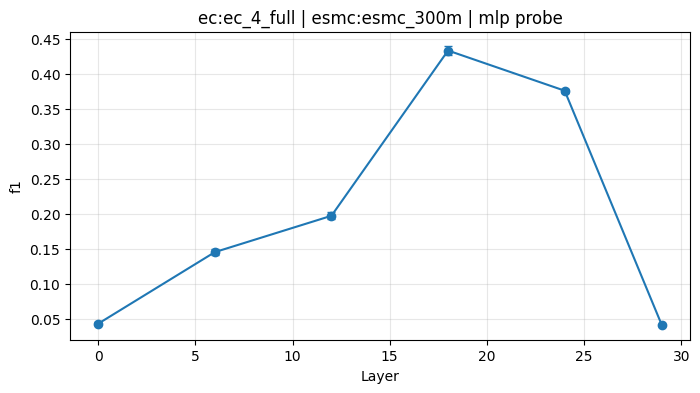

In [12]:
def choose_metric(results: pd.DataFrame, requested: str | None) -> str:
    if requested is not None:
        if requested not in results.columns:
            raise EmbeddingInputError(f"Requested metric {requested!r} is not present. Available: {list(results.columns)}")
        return requested
    preferred = ["accuracy", "macro_f1", "f1", "auroc", "spearmanr", "r2", "rmse", "mae"]
    for metric in preferred:
        if metric in results.columns:
            return metric
    metric_columns = [column for column in results.columns if column not in {"layer", "elapsed_seconds", "train_count", "val_count", "test_count"} and not column.endswith("_std")]
    if not metric_columns:
        raise EmbeddingInputError("No metric columns found in probe results.")
    return metric_columns[0]


metric = choose_metric(results, METRIC)
metric = "f1"

fig, ax = plt.subplots(figsize=(8, 4))
metric_std = f"{metric}_std"
if metric_std in results.columns:
    ax.errorbar(
        results["layer"],
        results[metric],
        yerr=results[metric_std].fillna(0.0),
        marker="o",
        capsize=3,
    )
else:
    ax.plot(results["layer"], results[metric], marker="o")
ax.set_xlabel("Layer")
ax.set_ylabel(metric)
ax.set_title(f"{dataset_entry.id} | {MODEL_CLASS}:{RESOLVED_MODEL_NAME} | {PROBE.kind} probe")
ax.grid(alpha=0.3)
plt.show()
